In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier

---

# Limpieza de Datos

## Ejercicio 1

In [2]:
df_datos_en_bruto = pd.read_csv("./usu_individual_T325.txt", sep=";", low_memory=False)
df_datos_en_bruto.head()

,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
0,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,8,0,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
1,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,9,0,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
2,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,1,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
3,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,2,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
4,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,3,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0


## Ejercicio 2

In [3]:
df_datos = df_datos_en_bruto[df_datos_en_bruto["H15"] == 1]

print("Eliminación de Individuos que no Completaron Encuesta")

print(f"Datos Originales: {len(df_datos_en_bruto)}")
print(f"Datos Incompletos: {len(df_datos_en_bruto) - len(df_datos)}")
print(f"Datos Restantes: {len(df_datos)}")

df_datos.head()

Eliminación de Individuos que no Completaron Encuesta
Datos Originales: 44946
Datos Incompletos: 4947
Datos Restantes: 39999


,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
2,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,1,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
3,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,2,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
4,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,3,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
5,TQRMNOTYPHKOKQCDEHNHB00867020,2025,3,1,4,1,42,S,27,528,...,0,0,0,0,1.0,1.0,1.0,NaN,1.0,1.0
6,TQRMNOQSSHKLKRCDEIHJF00868831,2025,3,1,1,1,44,N,31,140,...,0,0,0,0,3.0,2.0,NaN,4.0,4.0,2.0


## Ejercicio 3

In [4]:
columnas_a_mantener = [
    "REGION",   "MAS_500", "CH04",     "CH03",     "CH06",   "CH07",       "CH09",     "CH10",
    "NIVEL_ED", "ESTADO",  "CAT_OCUP", "CAT_INAC", "SECTOR", "PP02B",      "PP02C1",   "PP02C2",
    "PP02C3",   "PP02C4",  "PP02C5",   "PP02C6",   "PP02C7", "PP02C8",     "PP02D",    "PP02F",
    "PP02G",    "PP02H",   "PP02I",    "PP03C",    "PP03D",  "PP3E_TOT",   "PP3F_TOT", "PP03G",
    "PP03H",    "PP04A",   "PP04A1",   "PP04B1",   "PP04B2", "PP04B3_ANO", "PP04C",    "PP03I",
    "PP03J",    "PP03K",   "INTENSI",  "PP04G",    "P47T",   "EMPLEO"
]

df_datos = df_datos[columnas_a_mantener]

df_datos.head()

,REGION,MAS_500,CH04,CH03,CH06,CH07,CH09,CH10,NIVEL_ED,ESTADO,...,PP04B2,PP04B3_ANO,PP04C,PP03I,PP03J,PP03K,INTENSI,PP04G,P47T,EMPLEO
2,42,S,2,1,38,1,1,2,1,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,552000.0,NaN
3,42,S,1,2,39,1,1,2,4,1,...,0.0,0.0,1.0,2.0,2.0,0.0,2.0,8.0,400000.0,2.0
4,42,S,1,3,18,5,1,1,1,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
5,42,S,1,3,17,5,1,2,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
6,44,N,1,1,50,2,1,2,3,1,...,0.0,0.0,10.0,2.0,2.0,0.0,2.0,11.0,1200000.0,1.0


## Ejercicio 4

In [5]:
columnas_con_faltantes = [
    "EMPLEO",     "PP03C",    "PP03D",
    "PP3E_TOT",   "PP3F_TOT", "PP03G",
    "PP03H",      "PP03I",    "PP03J",
    "PP03K",      "PP04B1",   "PP04B2",
    "PP04B3_ANO", "PP04C",    "PP04A",
    "PP04A1",     "PP04G",    "INTENSI",
    #"SECTOR",
]

print("Eliminación de NA")
print(f"Antes:   {df_datos[columnas_con_faltantes].isna().sum().sum()} NA")
df_datos = df_datos.fillna({ columna: 0 for columna in columnas_a_mantener })
print(f"Después: {df_datos[columnas_con_faltantes].isna().sum().sum()} NA")

df_datos.head()

Eliminación de NA
Antes:   358794 NA
Después: 0 NA


,REGION,MAS_500,CH04,CH03,CH06,CH07,CH09,CH10,NIVEL_ED,ESTADO,...,PP04B2,PP04B3_ANO,PP04C,PP03I,PP03J,PP03K,INTENSI,PP04G,P47T,EMPLEO
2,42,S,2,1,38,1,1,2,1,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,552000.0,0.0
3,42,S,1,2,39,1,1,2,4,1,...,0.0,0.0,1.0,2.0,2.0,0.0,2.0,8.0,400000.0,2.0
4,42,S,1,3,18,5,1,1,1,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,42,S,1,3,17,5,1,2,3,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,44,N,1,1,50,2,1,2,3,1,...,0.0,0.0,10.0,2.0,2.0,0.0,2.0,11.0,1200000.0,1.0


## Ejercicio 5

In [6]:
print("Eliminación de Filas Sin Ingresos Totales")
print(f"Antes:   {len(df_datos)}")

df_datos = df_datos[df_datos["P47T"] >= 0]

print(f"Después: {len(df_datos)}")

df_datos.head()

Eliminación de Filas Sin Ingresos Totales
Antes:   39999
Después: 34355


,REGION,MAS_500,CH04,CH03,CH06,CH07,CH09,CH10,NIVEL_ED,ESTADO,...,PP04B2,PP04B3_ANO,PP04C,PP03I,PP03J,PP03K,INTENSI,PP04G,P47T,EMPLEO
2,42,S,2,1,38,1,1,2,1,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,552000.0,0.0
3,42,S,1,2,39,1,1,2,4,1,...,0.0,0.0,1.0,2.0,2.0,0.0,2.0,8.0,400000.0,2.0
4,42,S,1,3,18,5,1,1,1,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,42,S,1,3,17,5,1,2,3,3,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,44,N,1,1,50,2,1,2,3,1,...,0.0,0.0,10.0,2.0,2.0,0.0,2.0,11.0,1200000.0,1.0


## Ejercicio 6

In [7]:
print("Eliminación de Filas con Faltantes")
print(f"Antes:   {len(df_datos)}")

df_datos = df_datos.dropna()

print(f"Después: {len(df_datos)}")

Eliminación de Filas con Faltantes
Antes:   34355
Después: 34355


## Ejercicio 7

In [8]:
df_datos = df_datos.astype({
    columna: int
    for columna in [
        "PP03C",  "PP03D",  "PP03G",      "PP03H",
        "PP03I",  "PP03J",  "PP03K",      "INTENSI",
        "PP04A",  "PP04A1", "PP04G",      "SECTOR",
        "PP04B1", "PP04B2", "PP04B3_ANO", "PP04C",
        "EMPLEO",
    ]
})

df_datos.head()

,REGION,MAS_500,CH04,CH03,CH06,CH07,CH09,CH10,NIVEL_ED,ESTADO,...,PP04B2,PP04B3_ANO,PP04C,PP03I,PP03J,PP03K,INTENSI,PP04G,P47T,EMPLEO
2,42,S,2,1,38,1,1,2,1,3,...,0,0,0,0,0,0,0,0,552000.0,0
3,42,S,1,2,39,1,1,2,4,1,...,0,0,1,2,2,0,2,8,400000.0,2
4,42,S,1,3,18,5,1,1,1,3,...,0,0,0,0,0,0,0,0,0.0,0
5,42,S,1,3,17,5,1,2,3,3,...,0,0,0,0,0,0,0,0,0.0,0
6,44,N,1,1,50,2,1,2,3,1,...,0,0,10,2,2,0,2,11,1200000.0,1


In [9]:
columnas_a_convertir_a_dummy = [
    "ESTADO", "REGION",  "MAS_500", "CAT_OCUP", "CAT_INAC",
    "PP02B",  "PP02C1",  "PP02C2",  "PP02C3",   "PP02C4",
    "PP02C5", "PP02C6",  "PP02C7",  "PP02C8",   "PP02D",
    "PP02F",  "PP02G",   "PP02H",   "PP02I",    "PP03C",
              "PP03G",   "PP03H",   "PP03I",    "PP03J",
    "PP03K",  "INTENSI", "PP04A",   "PP04A1",   "PP04G",
]

descripcion_columnas = {
    "CH03": "Relación de Parentesco",
    "CH04": "Sexo",
    "CH06": "Edad",
    "CH07": "Estado Civil",
    "CH09": "¿Sabe leer y escribir?",
    "CH10": "¿Asiste o asistió a un establecimiento educativo?",

    "NIVEL_ED": "Nivel educativo",
    "PP3E_TOT": "Total de horas semanales trabajadas en ocupación principal",
    "PP3F_TOT": "Total de horas semanales trabajadas en otra ocupación",
    "PP04B1": "¿Presta servicios domésticos?",
    "PP04B2": "¿En cuántas casas trabaja?",
    "PP04B3_ANO": "¿Cuántos años hace que trabaja ahí?",
    "PP04C": "¿Cuántas personas trabajan ahí?",
    "P47T": "Monto de ingresos individuales",
    "EMPLEO": "Tipo de empleo",

    "ESTADO_1": "Condición de actividad: ocupado",
    "ESTADO_2": "Condición de actividad: desocupado",
    "ESTADO_3": "Condición de actividad: Inactivo",

    "REGION_1": "Región: Gran Buenos Aires",
    "REGION_40": "Región: Noroeste",
    "REGION_41": "Región: Noreste",
    "REGION_42": "Región: Cuyo",
    "REGION_43": "Región: Pampeana",
    "REGION_44": "Región: Patagonia",

    "MAS_500_N": "Aglomerado: menor a 500.000 habitantes",
    "MAS_500_S": "Aglomerado: mayor o igual a 500.000 habitantes",

    "CAT_OCUP_0": "Categoría ocupacional: No aplica",
    "CAT_OCUP_1": "Categoría ocupacional: Patrón",
    "CAT_OCUP_2": "Categoría ocupacional: Cuenta propia",
    "CAT_OCUP_3": "Categoría ocupacional: Obrero o empleado",
    "CAT_OCUP_4": "Categoría ocupacional: Trabajador no remunerado",
    "CAT_OCUP_9": "Categoría ocupacional: No sabe / no responde",

    "CAT_INAC_0": "Categoría de inactividad: No aplica",
    "CAT_INAC_1": "Categoría de inactividad: Jubilado / pensionado",
    "CAT_INAC_2": "Categoría de inactividad: Rentista",
    "CAT_INAC_3": "Categoría de inactividad: Estudiante",
    "CAT_INAC_4": "Categoría de inactividad: Ama de casa",
    "CAT_INAC_6": "Categoría de inactividad: Discapacitado",
    "CAT_INAC_7": "Categoría de inactividad: Otros",

    "PP02B_0": "¿Buscó trabajo en los últimos 30 días? No aplica",
    "PP02B_1": "¿Buscó trabajo en los últimos 30 días? Sí",
    "PP02B_2": "¿Buscó trabajo en los últimos 30 días? No",

    "PP02C1_0": "¿Buscó trabajo por contactos o entrevistas? No aplica",
    "PP02C1_1": "¿Buscó trabajo por contactos o entrevistas? Sí",
    "PP02C1_2": "¿Buscó trabajo por contactos o entrevistas? No",

    "PP02C2_0": "¿Buscó trabajo mandando CV? No aplica",
    "PP02C2_1": "¿Buscó trabajo mandando CV? Sí",
    "PP02C2_2": "¿Buscó trabajo mandando CV? No",

    "PP02C3_0": "¿Buscó trabajo presentándose en el lugar? No aplica",
    "PP02C3_1": "¿Buscó trabajo presentándose en el lugar? Sí",
    "PP02C3_2": "¿Buscó trabajo presentándose en el lugar? No",

    "PP02C4_0": "¿Buscó trabajo por su cuenta? No aplica",
    "PP02C4_1": "¿Buscó trabajo por su cuenta? Sí",
    "PP02C4_2": "¿Buscó trabajo por su cuenta? No",

    "PP02C5_0": "¿Buscó trabajo poniendo carteles? No aplica",
    "PP02C5_1": "¿Buscó trabajo poniendo carteles? Sí",
    "PP02C5_2": "¿Buscó trabajo poniendo carteles? No",

    "PP02C6_0": "¿Buscó trabajo a través de parientes / amigos? No aplica",
    "PP02C6_1": "¿Buscó trabajo a través de parientes / amigos? Sí",
    "PP02C6_2": "¿Buscó trabajo a través de parientes / amigos? No",

    "PP02C7_0": "¿Buscó trabajo por bolsa, listas, etc.? No aplica",
    "PP02C7_1": "¿Buscó trabajo por bolsa, listas, etc.? Sí",
    "PP02C7_2": "¿Buscó trabajo por bolsa, listas, etc.? No",

    "PP02C8_0": "¿Buscó trabajo de otra forma? No aplica",
    "PP02C8_1": "¿Buscó trabajo de otra forma? Sí",
    "PP02C8_2": "¿Buscó trabajo de otra forma? No",

    "PP02D_0": "¿Consultó amigos / parientes, puso carteles, quiso ponerse por su cuenta? No aplica",
    "PP02D_1": "¿Consultó amigos / parientes, puso carteles, quiso ponerse por su cuenta? Sí",
    "PP02D_2": "¿Consultó amigos / parientes, puso carteles, quiso ponerse por su cuenta? No",

    "PP02F_0": "¿Intentó conseguir trabajo en los últimos 30 días? No aplica",
    "PP02F_1": "¿Intentó conseguir trabajo en los últimos 30 días? Sí",
    "PP02F_2": "¿Intentó conseguir trabajo en los últimos 30 días? No",

    "PP02G_0": "¿Puede empezar a trabajar? No aplica",
    "PP02G_1": "¿Puede empezar a trabajar? Sí",
    "PP02G_2": "¿Puede empezar a trabajar? No",

    "PP02H_0": "¿Buscó trabajo en los últimos 12 meses? No aplica",
    "PP02H_1": "¿Buscó trabajo en los últimos 12 meses? Sí",
    "PP02H_2": "¿Buscó trabajo en los últimos 12 meses? No",

    "PP02I_0": "¿Trabajó en los últimos 12 meses? No aplica",
    "PP02I_1": "¿Trabajó en los últimos 12 meses? Sí",
    "PP02I_2": "¿Trabajó en los últimos 12 meses? No",

    "PP03C_0": "¿Cuántos empleos tuvo la semana pasada? No aplica",
    "PP03C_1": "¿Cuántos empleos tuvo la semana pasada? Uno sólo",
    "PP03C_2": "¿Cuántos empleos tuvo la semana pasada? Más de uno",

    "PP03D": "Cantidad de ocupaciones",

    "PP03G_0": "¿Quería trabajar más horas la semana pasada? No aplica",
    "PP03G_1": "¿Quería trabajar más horas la semana pasada? Sí",
    "PP03G_2": "¿Quería trabajar más horas la semana pasada? No",
    "PP03G_9": "¿Quería trabajar más horas la semana pasada? No sabe / no responde",

    "PP03H_0": "¿Qué hubiese hecho si conseguía más horas? No aplica",
    "PP03H_1": "¿Qué hubiese hecho si conseguía más horas? Las hubiese trabajado",
    "PP03H_2": "¿Qué hubiese hecho si conseguía más horas? Las hubiese empezado más tarde",
    "PP03H_3": "¿Qué hubiese hecho si conseguía más horas? No hubiese podido",
    "PP03H_9": "¿Qué hubiese hecho si conseguía más horas? No sabe / no responde",

    "PP03I_0": "¿Buscó trabajar más horas? No aplica",
    "PP03I_1": "¿Buscó trabajar más horas? Sí",
    "PP03I_2": "¿Buscó trabajar más horas? No",
    "PP03I_9": "¿Buscó trabajar más horas? No sabe / no responde",

    "PP03J_0": "¿Estuvo buscando otro empleo? No aplica",
    "PP03J_1": "¿Estuvo buscando otro empleo? Sí",
    "PP03J_2": "¿Estuvo buscando otro empleo? No",
    "PP03J_9": "¿Estuvo buscando otro empleo? No sabe / no responde",

    "PP03K_0": "¿Por qué estuvo buscando trabajo? No aplica",
    "PP03K_1": "¿Por qué estuvo buscando trabajo? Quería cambiar",
    "PP03K_2": "¿Por qué estuvo buscando trabajo? Quería agregar",
    "PP03K_3": "¿Por qué estuvo buscando trabajo? Se terminaba el actual",
    "PP03K_4": "¿Por qué estuvo buscando trabajo? Estaba sin trabajo",

    "INTENSI_0": "Intensidad laboral: No aplica",
    "INTENSI_1": "Intensidad laboral: Subocupado por insuficiencia horaria",
    "INTENSI_2": "Intensidad laboral: Ocupado pleno",
    "INTENSI_3": "Intensidad laboral: Sobreocupado",
    "INTENSI_4": "Intensidad laboral: Ocupado que no trabajó en la semana",

    "PP04A_0": "Jurisdicción del trabajo: No aplica",
    "PP04A_1": "Jurisdicción del trabajo: Estatal",
    "PP04A_2": "Jurisdicción del trabajo: Privado",
    "PP04A_3": "Jurisdicción del trabajo: Otro",

    "PP04A1_0": "Nivel del trabajo: No aplica",
    "PP04A1_1": "Nivel del trabajo: Nacional",
    "PP04A1_2": "Nivel del trabajo: Provincial",
    "PP04A1_3": "Nivel del trabajo: Municipal",
    "PP04A1_9": "Nivel del trabajo: No sabe / no responde",

    "PP04G_0": "Lugar de trabajo: No aplica",
    "PP04G_2": "Lugar de trabajo: Puesto o kiosco fijo callejero",
    "PP04G_3": "Lugar de trabajo: Vehículo",
    "PP04G_4": "Lugar de trabajo: Vehículo de transporte",
    "PP04G_5": "Lugar de trabajo: Obra de construcción o similar",
    "PP04G_6": "Lugar de trabajo: Vivienda",
    "PP04G_7": "Lugar de trabajo: Vivienda de socio",
    "PP04G_8": "Lugar de trabajo: Domicilio de cliente",
    "PP04G_9": "Lugar de trabajo: Espacio público",
    "PP04G_10": "Lugar de trabajo: Otro lugar",
    "PP04G_11": "Lugar de trabajo: Local u oficina",
    "PP04G_12": "Lugar de trabajo: Vivienda exclusiva",
    "PP04G_13": "Lugar de trabajo: Chacra o finca",

    "SECTOR_0": "Sector: No aplica",
    "SECTOR_1": "Sector: Formal",
    "SECTOR_2": "Sector: Informal",
    "SECTOR_3": "Sector: Hogares",
    "SECTOR_9": "Sector: No sabe / no responde"
}

df_datos = pd.get_dummies(df_datos, columns=columnas_a_convertir_a_dummy, drop_first=False)
df_datos.head()

,CH04,CH03,CH06,CH07,CH09,CH10,NIVEL_ED,SECTOR,PP03D,PP3E_TOT,...,PP04G_4,PP04G_5,PP04G_6,PP04G_7,PP04G_8,PP04G_9,PP04G_10,PP04G_11,PP04G_12,PP04G_13
2,2,1,38,1,1,2,1,0,0,0.0,...,False,False,False,False,False,False,False,False,False,False
3,1,2,39,1,1,2,4,2,0,36.0,...,False,False,False,False,True,False,False,False,False,False
4,1,3,18,5,1,1,1,0,0,0.0,...,False,False,False,False,False,False,False,False,False,False
5,1,3,17,5,1,2,3,0,0,0.0,...,False,False,False,False,False,False,False,False,False,False
6,1,1,50,2,1,2,3,1,0,35.0,...,False,False,False,False,False,False,False,True,False,False


## Ejercicio 8

In [10]:
df_clean = df_datos.copy()
df_clean = df_clean[df_clean["PP04C"] != 99]

df_clean["CH07"] = np.where(df_clean["CH07"] == 5, True, False)
df_clean["CH09"] = np.where(df_clean["CH09"] == 1, True, False)

df_clean["NIVEL_ED"] = df_clean["NIVEL_ED"].replace(7, 0) 

df_clean[["PP04C", "CH07", "CH09", "NIVEL_ED"]]

,PP04C,CH07,CH09,NIVEL_ED
2,0,False,True,1
3,1,False,True,4
4,0,True,True,1
5,0,True,True,3
6,10,False,True,3
...,...,...,...,...
44939,0,True,True,3
44940,0,True,True,1
44942,8,False,True,6
44943,3,False,True,6


# Clustering

## Ejercicio 9

In [11]:
df_clustering = pd.get_dummies(df_clean, columns=["SECTOR"], drop_first=False)
df_clustering.head()

,CH04,CH03,CH06,CH07,CH09,CH10,NIVEL_ED,PP03D,PP3E_TOT,PP3F_TOT,...,PP04G_9,PP04G_10,PP04G_11,PP04G_12,PP04G_13,SECTOR_0,SECTOR_1,SECTOR_2,SECTOR_3,SECTOR_9
2,2,1,38,False,True,2,1,0,0.0,0.0,...,False,False,False,False,False,True,False,False,False,False
3,1,2,39,False,True,2,4,0,36.0,0.0,...,False,False,False,False,False,False,False,True,False,False
4,1,3,18,True,True,1,1,0,0.0,0.0,...,False,False,False,False,False,True,False,False,False,False
5,1,3,17,True,True,2,3,0,0.0,0.0,...,False,False,False,False,False,True,False,False,False,False
6,1,1,50,False,True,2,3,0,35.0,0.0,...,False,False,True,False,False,False,True,False,False,False


## Ejercicio 10

In [12]:
scaler = StandardScaler().set_output(transform="pandas")
df_clustering_escalado = scaler.fit_transform(df_clustering)

pca = PCA(n_components=2, random_state=20)
componentes_principales = pca.fit_transform(df_clustering_escalado)

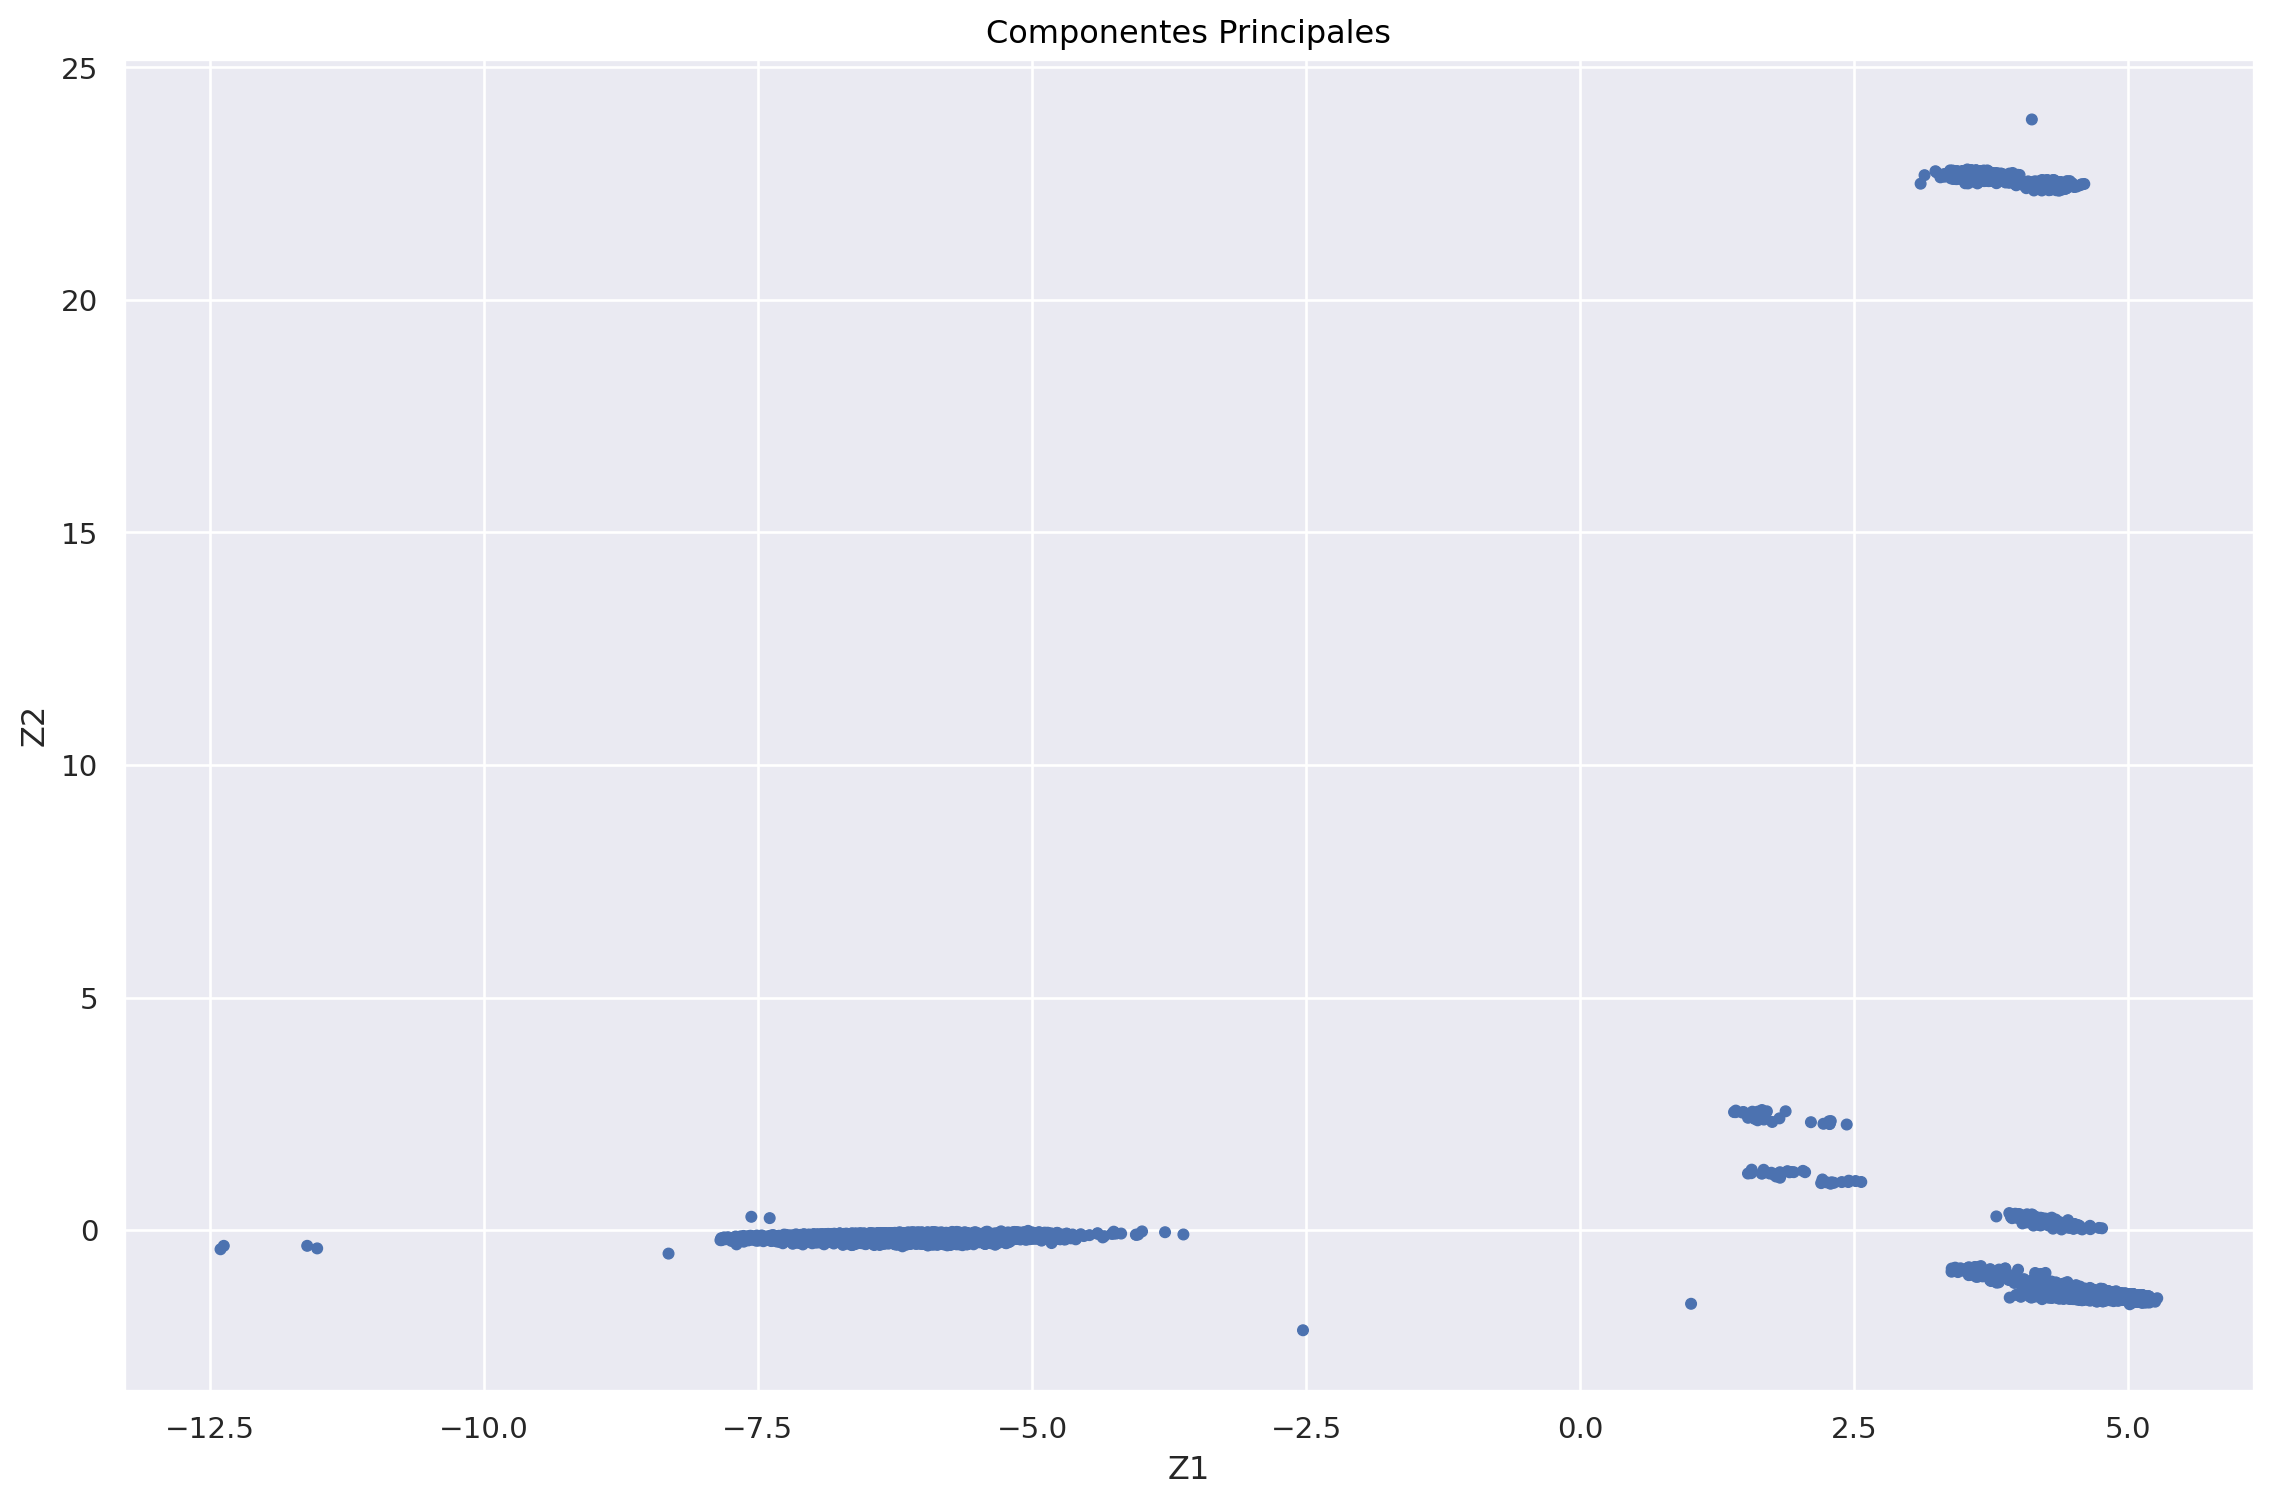

In [13]:
(
    so.Plot(
        x=componentes_principales[:, 0],
        y=componentes_principales[:, 1]
    )
    .add(so.Dot(pointsize=4))
    .label(x="Z1", y="Z2")
    .layout(size=(12, 8))
    .label(title="Componentes Principales")
)

A simple vista se pueden considerar tres regiones: la horizontal con Z1 entre -15 y -2.5; la horizontal que está con Z2 entre -25 y -20; y la restante.

## Ejercicio 11

Para este ejercicio se utilizará el algoritmo de K-Means. Además, para la estimación del hiperparámetro óptimo se hará uso del método del codo, es decir, se buscará un cambio en la pendiente del gráfico de Inercia Vs. K.

In [14]:
metricas = []
random_state = 20
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=random_state)
    kmeans.fit(df_clustering_escalado)
        
    metricas.append([k, kmeans.inertia_])

metricas = pd.DataFrame(metricas, columns=["k", "inercia"])

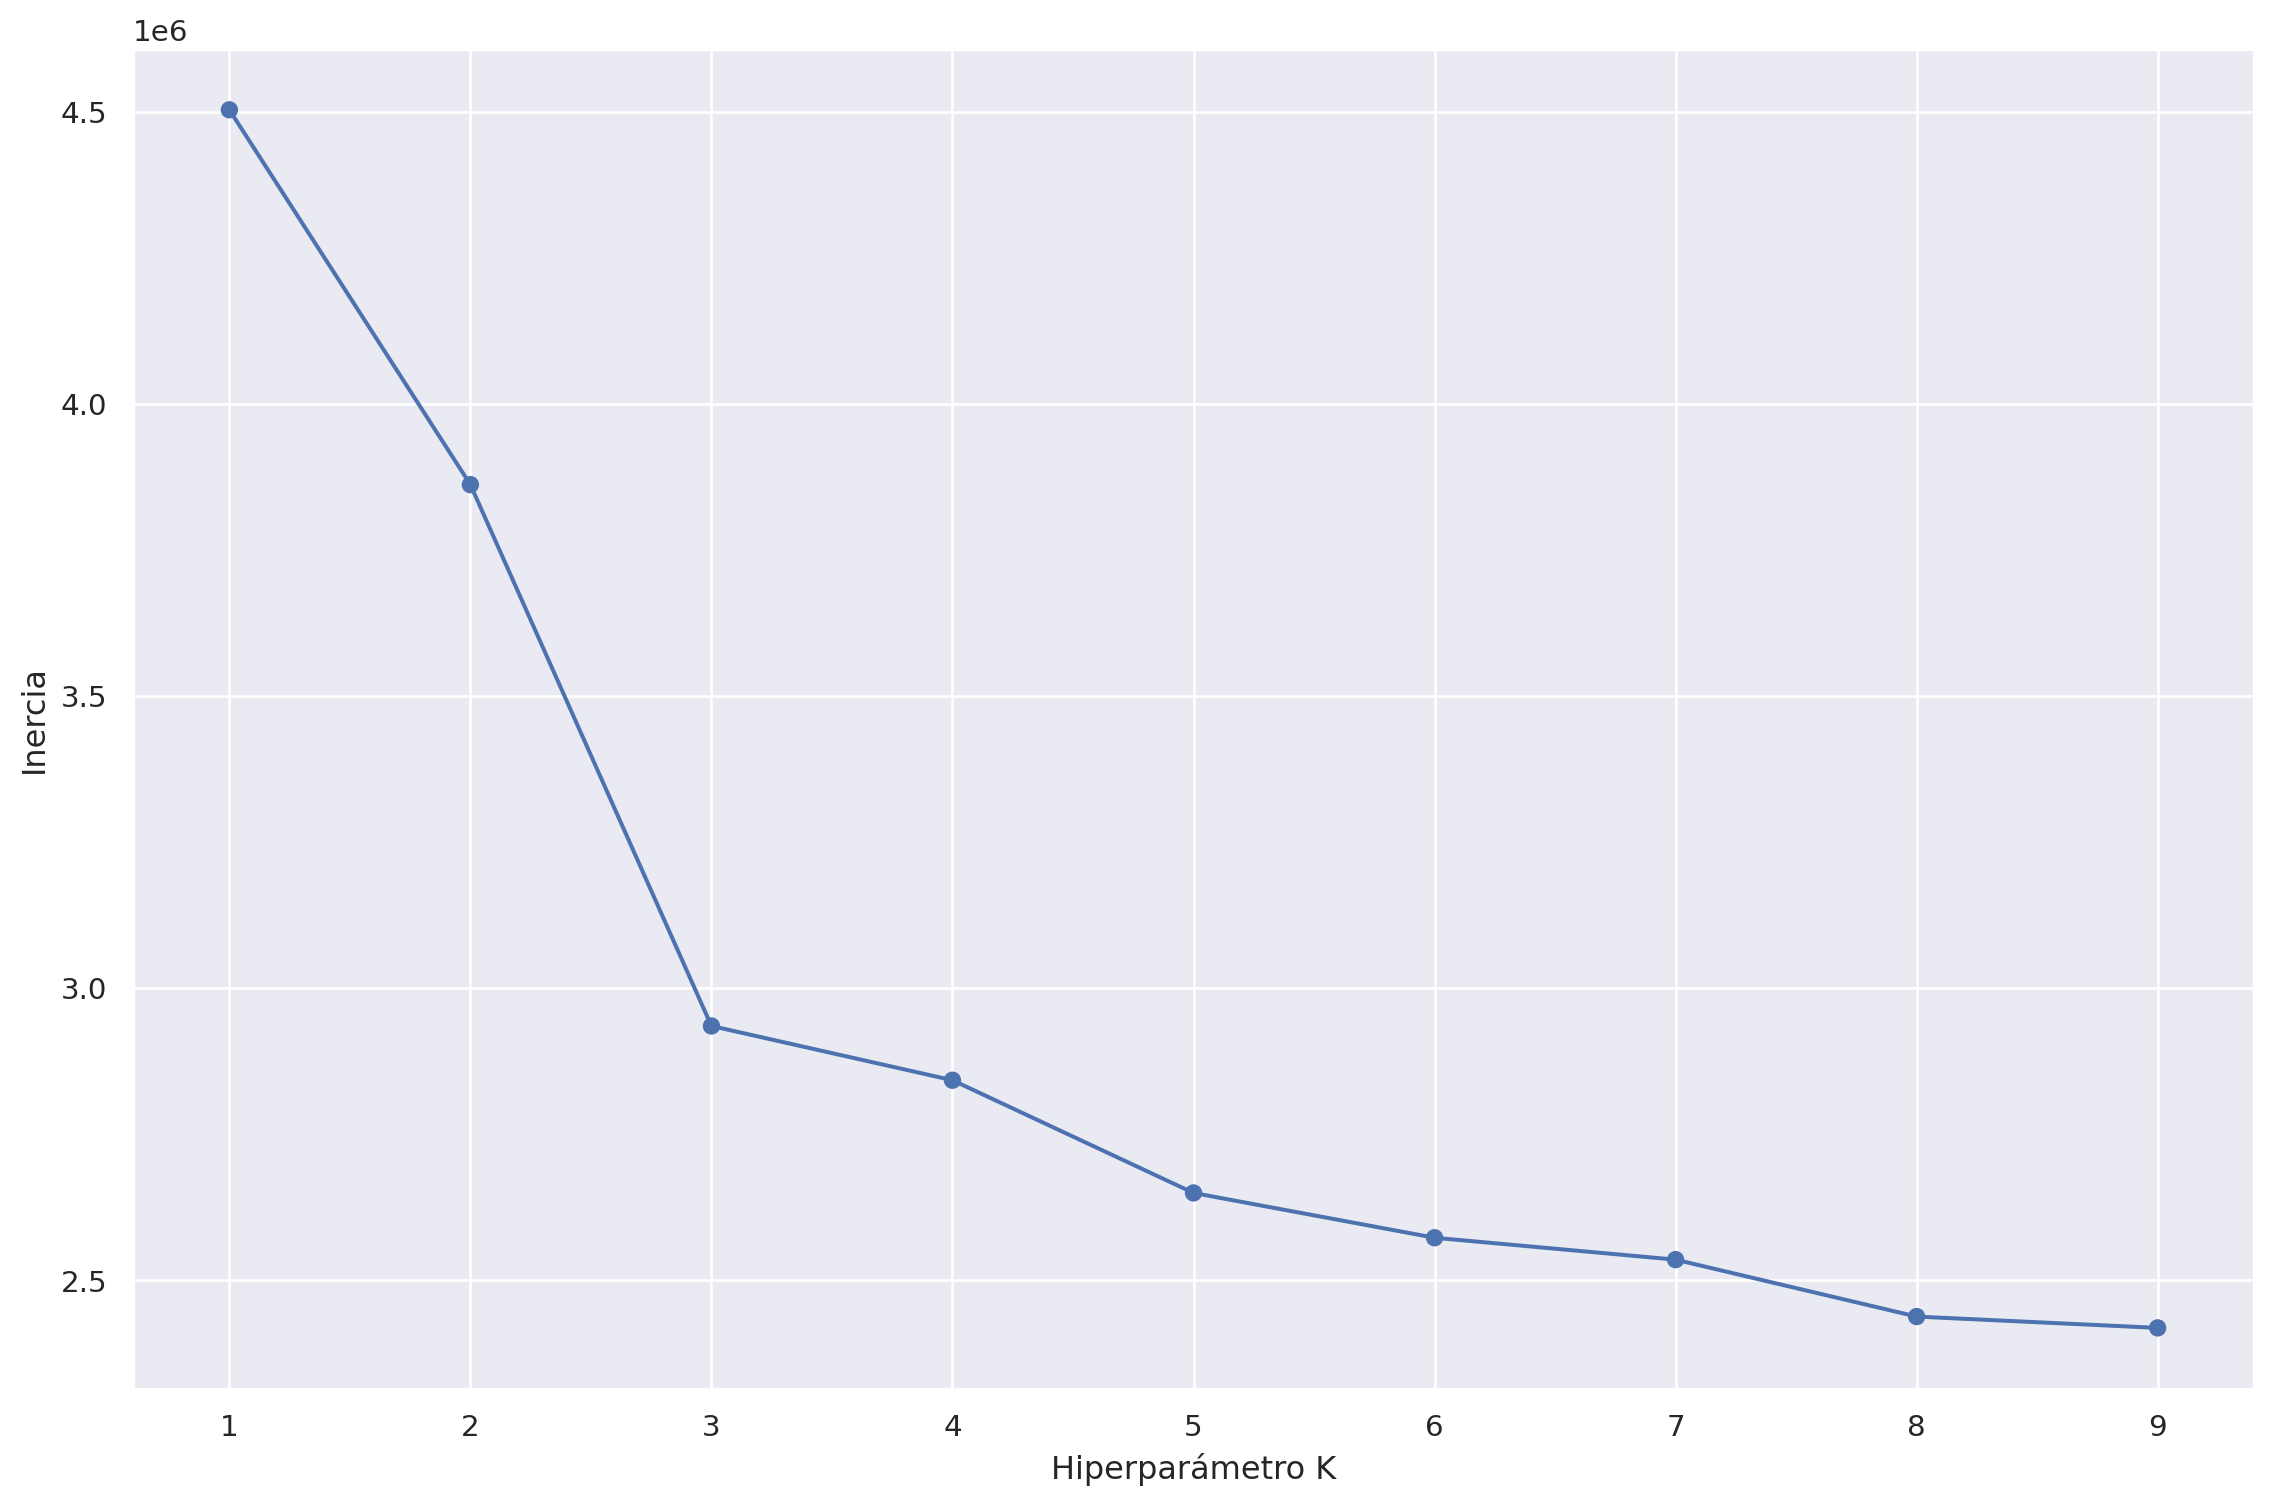

In [15]:
(
    so.Plot(data=metricas, x="k", y="inercia")
    .add(so.Line())
    .add(so.Dot())
    .layout(size=(12, 8))
    .label(x="Hiperparámetro K", y="Inercia")
    .scale(x=so.Continuous().tick(every=1)) 
)

## Ejercicio 12

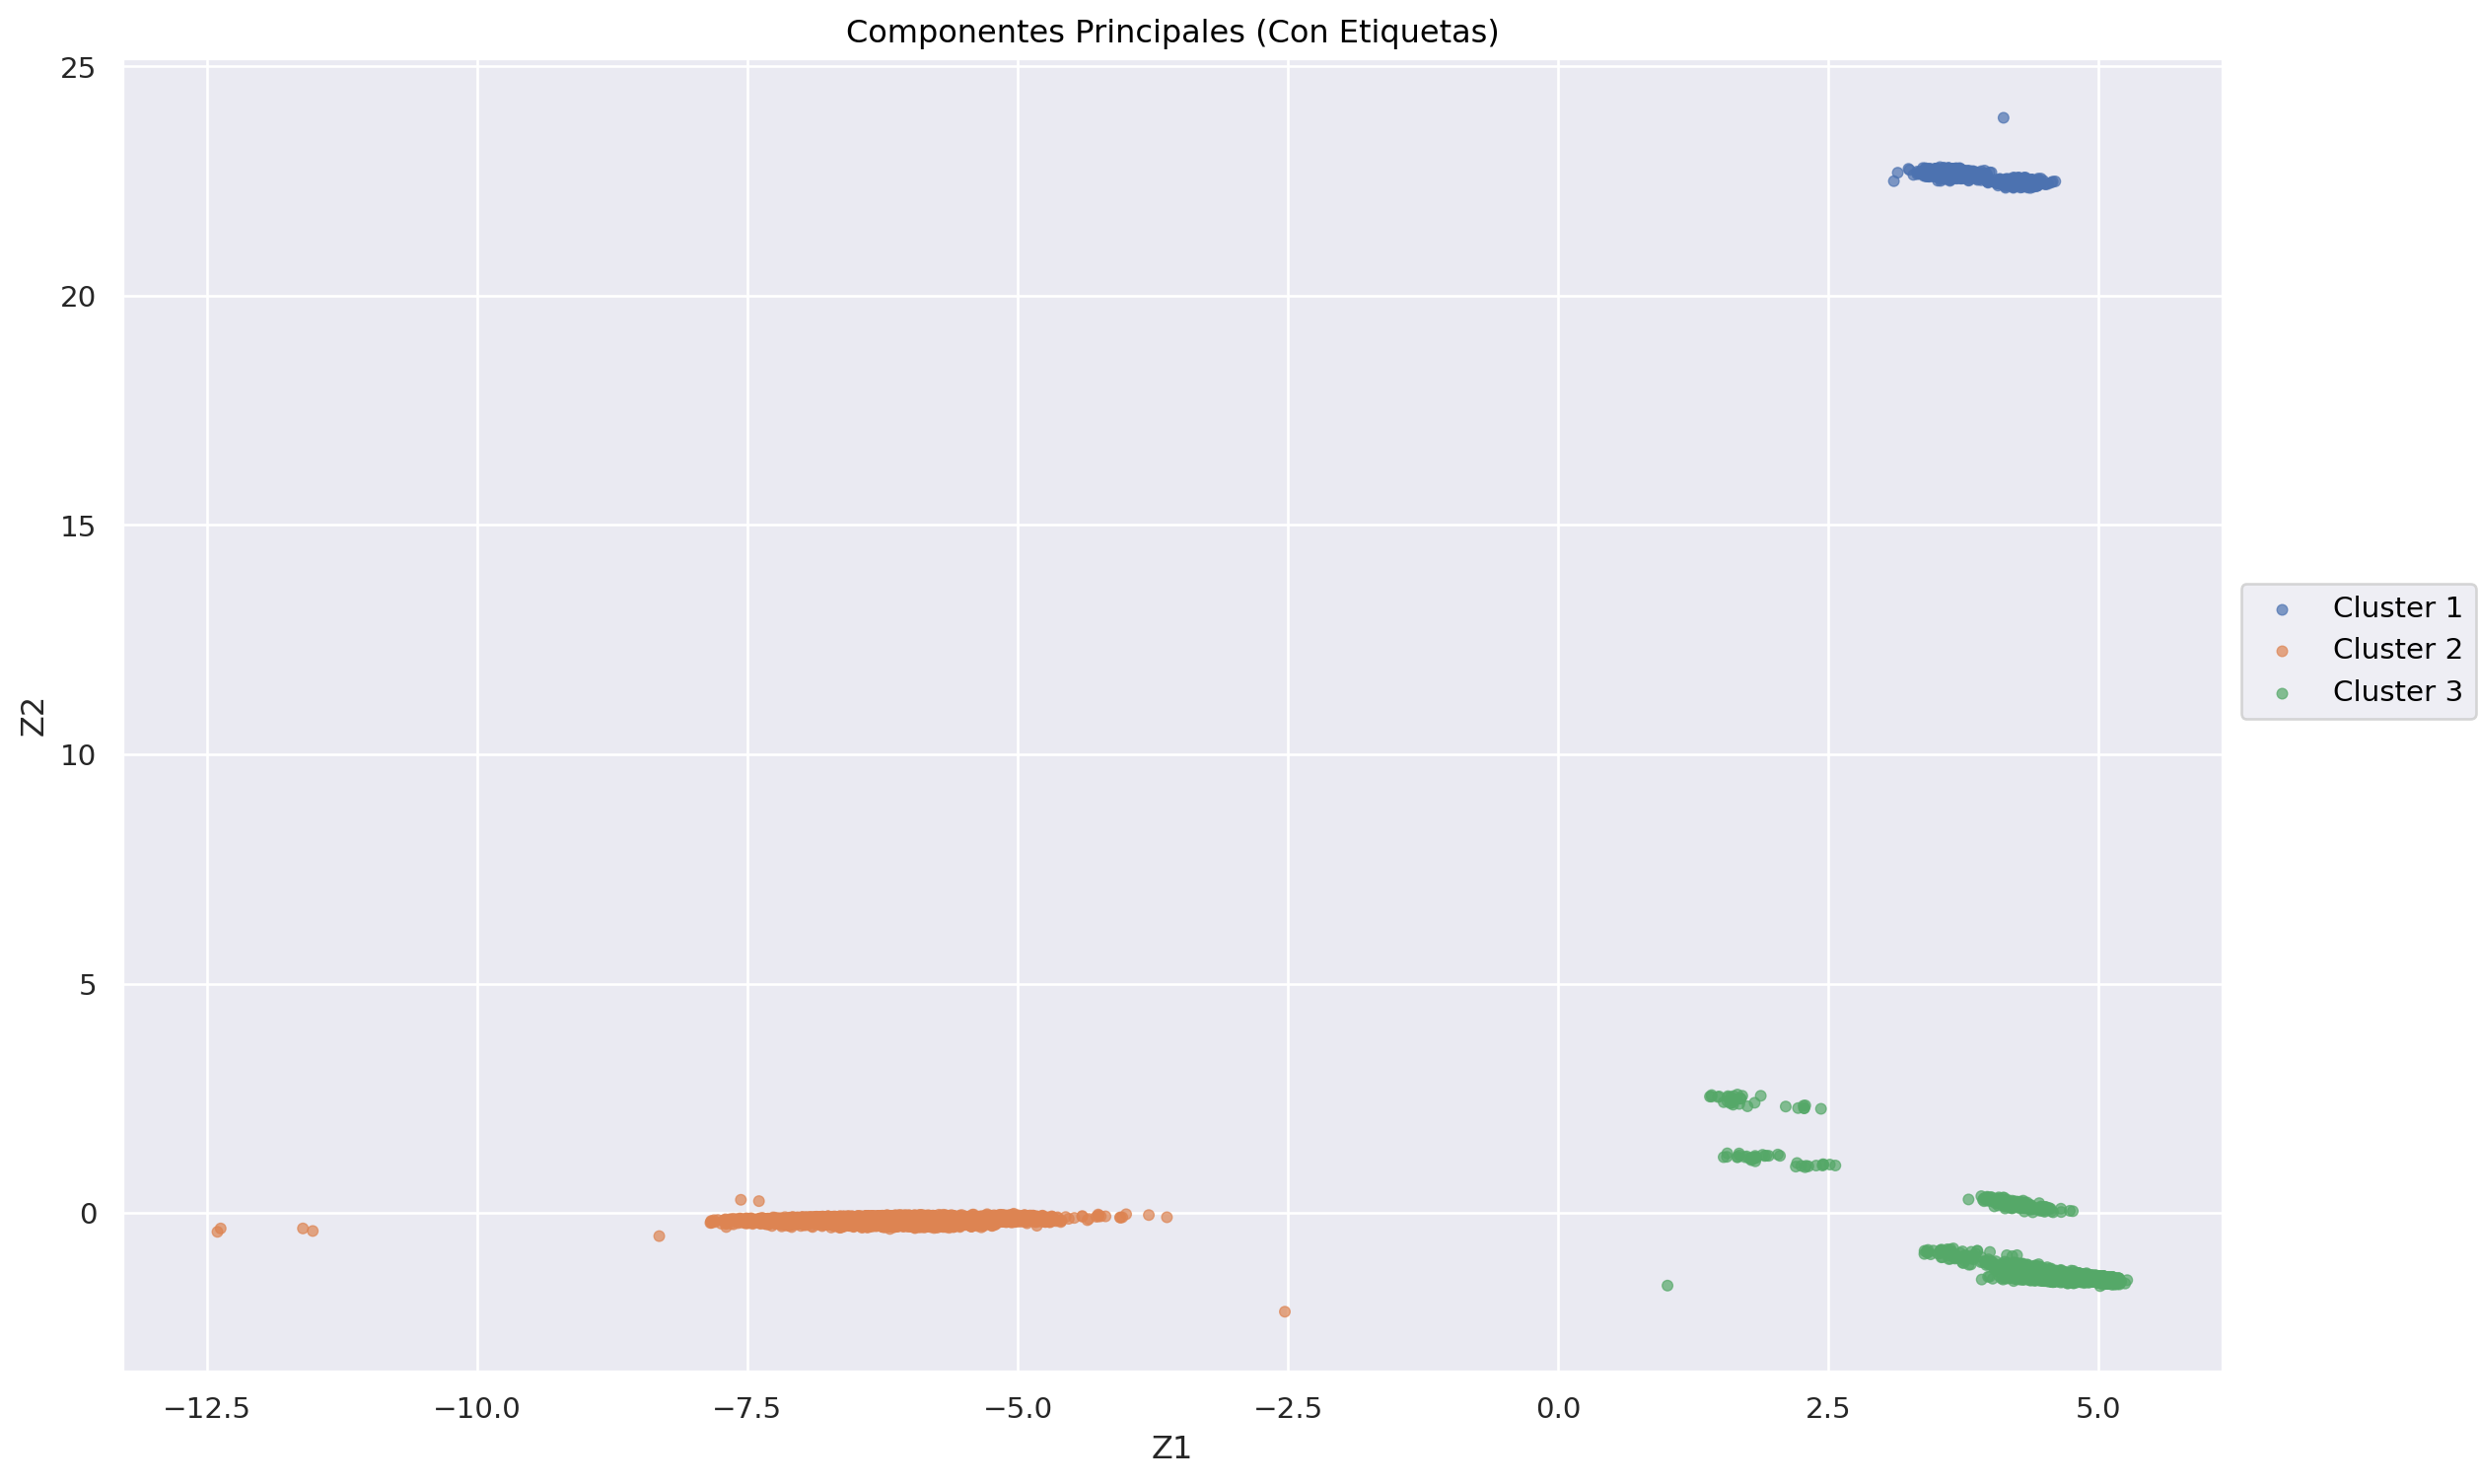

In [16]:
clustering = KMeans(n_clusters=3, random_state=random_state)
clustering.fit(df_clustering_escalado)
etiquetas = np.array([f"Cluster {nombre + 1}" for nombre in clustering.labels_])

(
    so.Plot(
        x=componentes_principales[:, 0],
        y=componentes_principales[:, 1],
        color=etiquetas
    )
    .add(so.Dot(alpha=0.7, pointsize=4))
    .label(x="Z1", y="Z2")
    .layout(size=(12, 8))
    .scale(color=so.Nominal(order=np.unique(etiquetas).tolist()))
    .label(title="Componentes Principales (Con Etiquetas)")
)

## Ejercicio 13

La idea para este ejercicio es analizar los centroides de cada cluster, obteniendo las columnas que tienen mayores valores absolutos, reescalándolos y discretizándolos. Todo esto para intentar obtener una idea de cuáles son las características predominantes de cada cluster. Además, este es procedimiento se va a realizar para las variables numéricas y las dummy, pero por separado, ya que la alta presencia de variables dummy puede opacar la influencia de las numéricas. De este modo, para cada tipo de variable, se obtendrán las 5 variables principales.

In [17]:
valores_validos_discretos = {
    columna: np.array(sorted(df_clustering[columna].unique()))
    for columna in df_clustering.columns
}

def discretizar(valor, posibles):
    return posibles[np.abs(posibles - valor).argmin()]

df_centroides = pd.DataFrame(
    data=clustering.cluster_centers_,
    index=np.unique(etiquetas),
    columns=df_clustering.columns
)

df_centroides_reescalados = pd.DataFrame(
    data=scaler.inverse_transform(df_centroides),
    index=df_centroides.index,
    columns=df_centroides.columns
)

df_centroides_reescalados_discretos = pd.DataFrame(columns=df_clustering.columns, dtype="string")
for columna, valores in valores_validos_discretos.items():
    df_centroides_reescalados_discretos[columna] = (
        df_centroides_reescalados[columna]
        .apply(discretizar, posibles=valores)
    )

def obtener_columnas_caracteristicas(df, n):
    for cluster in df.index:
        caracteristicas = pd.DataFrame(
            df
            .loc[cluster]
            .abs()
            .sort_values(ascending=False)
            .head(n)
        )

        caracteristicas["reescalado"]   = df_centroides_reescalados.loc[cluster, caracteristicas.index]
        caracteristicas["discretizado"] = df_centroides_reescalados_discretos.loc[cluster, caracteristicas.index]
        caracteristicas["descripcion"]  = [descripcion_columnas[columna] for columna in caracteristicas.index]

        caracteristicas.columns = ["Normalizado", "Reescalado", "Discretizado", "Descripción"]

        print(f"Las {n} columnas más importantes para el cluster {cluster}")
        display(caracteristicas)
        print("\n")


Una vez creada la función para obtener las columnas características, se va a ejecutar primero con las columnas dummy y después con las continuas.

In [18]:
pd.set_option("display.max_colwidth", 100)

columnas_dummy = [
    columna
    for columna in df_centroides.columns
    if any(columna.startswith(prefijo) for prefijo in ["SECTOR", *columnas_a_convertir_a_dummy])
]

obtener_columnas_caracteristicas(
  df=df_centroides[columnas_dummy],
  n=5
)

Las 5 columnas más importantes para el cluster Cluster 1


,Normalizado,Reescalado,Discretizado,Descripción
PP02B_1,5.174158,1.000000e+00,True,¿Buscó trabajo en los últimos 30 días? Sí
PP02C2_0,5.174158,-2.886580e-15,False,¿Buscó trabajo mandando CV? No aplica
PP02C1_0,5.174158,-2.886580e-15,False,¿Buscó trabajo por contactos o entrevistas? No aplica
PP02C7_0,5.174158,-2.886580e-15,False,"¿Buscó trabajo por bolsa, listas, etc.? No aplica"
PP02C8_0,5.174158,-2.886580e-15,False,¿Buscó trabajo de otra forma? No aplica




Las 5 columnas más importantes para el cluster Cluster 2


,Normalizado,Reescalado,Discretizado,Descripción
ESTADO_1,1.151826,0.999929,True,Condición de actividad: ocupado
PP03I_0,1.151826,0.000071,False,¿Buscó trabajar más horas? No aplica
PP03G_0,1.151826,0.000071,False,¿Quería trabajar más horas la semana pasada? No aplica
INTENSI_0,1.151826,0.000071,False,Intensidad laboral: No aplica
PP03J_0,1.151826,0.000071,False,¿Estuvo buscando otro empleo? No aplica




Las 5 columnas más importantes para el cluster Cluster 3


,Normalizado,Reescalado,Discretizado,Descripción
ESTADO_3,0.929658,0.995985,True,Condición de actividad: Inactivo
PP02I_0,0.929658,0.004015,False,¿Trabajó en los últimos 12 meses? No aplica
CAT_INAC_0,0.929600,0.004073,False,Categoría de inactividad: No aplica
PP02H_0,0.928743,0.004933,False,¿Buscó trabajo en los últimos 12 meses? No aplica
PP02F_0,0.920553,0.013193,False,¿Intentó conseguir trabajo en los últimos 30 días? No aplica


A partir de las variables dummy se puede ver lo siguiente:

**Cluster 1**: son individuos que han estado buscando trabajo, pero no informaron de qué forma, puesto que las columnas más predominantes son las que indican la no respuesta de la pregunta.

**Cluster 2**: son individuos que están actualmente con un empleo, pero en vez de responder que no buscaron trabajo, omitieron esas preguntas.

**Cluster 3**: son individuos que están inactivos, y que nuevamente no respondieron las preguntas de si estaban buscando trabajo.

En grandes rasgos, y sólo con el análisis parcial de las variables dummy, se puede ver que el **Cluster 1** representa a las personas en busca de trabajo (no necesariamente desempleados); el **Cluster 2** representa a los empleados; y por último el **Cluster 3**, a los inactivos.

In [19]:
obtener_columnas_caracteristicas(
  df=df_centroides[df_centroides.columns.difference(columnas_dummy)],
  n=8
)

Las 8 columnas más importantes para el cluster Cluster 1


,Normalizado,Reescalado,Discretizado,Descripción
PP04B1,0.853038,-3.996803e-15,0,¿Presta servicios domésticos?
EMPLEO,0.785789,-2.331468e-15,0,Tipo de empleo
PP3E_TOT,0.653444,-1.776357e-14,0.0,Total de horas semanales trabajadas en ocupación principal
PP04C,0.612936,-7.993606e-15,0,¿Cuántas personas trabajan ahí?
P47T,0.351916,1.550929e+05,155000.0,Monto de ingresos individuales
CH06,0.311052,3.336681e+01,33,Edad
CH10,0.303132,1.864681e+00,2,¿Asiste o asistió a un establecimiento educativo?
CH07,0.240500,5.957447e-01,True,Estado Civil




Las 8 columnas más importantes para el cluster Cluster 2


,Normalizado,Reescalado,Discretizado,Descripción
PP04B1,1.131869,1.918568e+00,2.0,¿Presta servicios domésticos?
EMPLEO,1.042639,1.461423e+00,1.0,Tipo de empleo
PP3E_TOT,0.867035,3.543982e+01,35.0,Total de horas semanales trabajadas en ocupación principal
PP04C,0.813286,5.031161e+00,5.0,¿Cuántas personas trabajan ahí?
CH10,0.437337,1.926768e+00,2.0,¿Asiste o asistió a un establecimiento educativo?
NIVEL_ED,0.357633,4.125998e+00,4.0,Nivel educativo
P47T,0.352200,1.053303e+06,1054000.0,Monto de ingresos individuales
PP03D,0.272862,2.302481e-01,0.0,Cantidad de ocupaciones




Las 8 columnas más importantes para el cluster Cluster 3


,Normalizado,Reescalado,Discretizado,Descripción
PP04B1,0.853038,3.375078e-14,0.0,¿Presta servicios domésticos?
EMPLEO,0.785789,5.195844e-14,0.0,Tipo de empleo
PP3E_TOT,0.653444,-1.058709e-12,0.0,Total de horas semanales trabajadas en ocupación principal
PP04C,0.612936,-8.437695e-15,0.0,¿Cuántas personas trabajan ahí?
CH10,0.372247,1.552229e+00,2.0,¿Asiste o asistió a un establecimiento educativo?
NIVEL_ED,0.298640,3.130614e+00,3.0,Nivel educativo
P47T,0.259608,2.728462e+05,273000.0,Monto de ingresos individuales
PP03D,0.205644,9.353629e-15,0.0,Cantidad de ocupaciones


In [20]:
df_componentes = pd.DataFrame(
    data=pca.components_.T,
    index=df_clustering.columns,
    columns=["PC1", "PC2"]
)

for componente in df_componentes.columns:
    caracteristicas = pd.DataFrame(
        data=df_componentes[componente].sort_values(ascending=False).head(5)
    )

    caracteristicas["descripción"] = [descripcion_columnas[columna] for columna in caracteristicas.index]

    display(caracteristicas)

,PC1,descripción
PP04A_0,0.186024,Jurisdicción del trabajo: No aplica
INTENSI_0,0.186024,Intensidad laboral: No aplica
SECTOR_0,0.186024,Sector: No aplica
PP03G_0,0.186024,¿Quería trabajar más horas la semana pasada? No aplica
PP03I_0,0.186024,¿Buscó trabajar más horas? No aplica


,PC2,descripción
PP02B_1,0.224056,¿Buscó trabajo en los últimos 30 días? Sí
PP02C8_2,0.222971,¿Buscó trabajo de otra forma? No
ESTADO_2,0.218923,Condición de actividad: desocupado
PP02C4_2,0.216780,¿Buscó trabajo por su cuenta? No
PP02C7_2,0.213485,"¿Buscó trabajo por bolsa, listas, etc.? No"


A partir de las variables numéricas se puede ver:

**Cluster 1**: son individuos que no presentan empleos, pero que igualmente cuentan con ingresos mensuales.

**Cluster 2**: son individuos que cuentan con empleo formal, en el cual trabajan varias horas semanales, y presentan los mayores ingresos mensuales de los tres clusters.

**Cluster 3**: son individuos similares a los del primer cluster, aunque entre estos aparece el nivel educativo y la asistencia a establecimientos educactivos como columnas caracterísiticas; además se puede ve que los ingresos mensuales de este grupo son casi el doble de los del primer cluster.

En grandes rasgos, a partir de las variables numéricas, se puede decir que el **Cluster 1** y **Cluster 3** son bastantes similares, ya que ambos no responden el tipo de empleo, pero obtienen ingresos mensuales, por lo que uno podría decir que pueden ser personas que o bien no tengan empleo fijo, o bien sean jubilados. Por otro lado, el **Cluster 2** destaca por caracterizar a las personas con empleos formales y con ingresos mucho más altos que los otros clusters.


Por lo tanto, si se unifican ambos análisis, se puede decir lo siguiente:
- **Cluster 1**: individuos activos, sin trabajo formal fijo, pero que están en busca de empleo
- **Cluster 2**: individuos activos, con trabajo formal fijo e ingresos altos
- **Cluster 3**: individuos inactivos, sin trabajo ni intención de buscar, pero con ingresos fijos, posiblemente jubilados

Ahora se va a realizar un análisis de las componentes primarias, para ver si concuerdan con lo anterior.

In [21]:
df_componentes = pd.DataFrame(
    data=pca.components_.T,
    index=df_clustering.columns,
    columns=["PC1", "PC2"]
)

for componente in df_componentes.columns:
    caracteristicas = pd.DataFrame(
        data=df_componentes[componente].sort_values(ascending=False)
    )

    caracteristicas["descripción"] = [descripcion_columnas[columna] for columna in caracteristicas.index]

    caracteristicas.columns = ["Coeficiente", "Descripción"]

    display(caracteristicas)

,Coeficiente,Descripción
PP04A_0,0.186024,Jurisdicción del trabajo: No aplica
INTENSI_0,0.186024,Intensidad laboral: No aplica
SECTOR_0,0.186024,Sector: No aplica
PP03G_0,0.186024,¿Quería trabajar más horas la semana pasada? No aplica
PP03I_0,0.186024,¿Buscó trabajar más horas? No aplica
...,...,...
PP02H_0,-0.174617,¿Buscó trabajo en los últimos 12 meses? No aplica
CAT_INAC_0,-0.174749,Categoría de inactividad: No aplica
PP02I_0,-0.174759,¿Trabajó en los últimos 12 meses? No aplica
PP04B1,-0.183903,¿Presta servicios domésticos?


,Coeficiente,Descripción
PP02B_1,0.224056,¿Buscó trabajo en los últimos 30 días? Sí
PP02C8_2,0.222971,¿Buscó trabajo de otra forma? No
ESTADO_2,0.218923,Condición de actividad: desocupado
PP02C4_2,0.216780,¿Buscó trabajo por su cuenta? No
PP02C7_2,0.213485,"¿Buscó trabajo por bolsa, listas, etc.? No"
...,...,...
PP02C3_0,-0.224056,¿Buscó trabajo presentándose en el lugar? No aplica
PP02C2_0,-0.224056,¿Buscó trabajo mandando CV? No aplica
PP02C4_0,-0.224056,¿Buscó trabajo por su cuenta? No aplica
PP02C1_0,-0.224056,¿Buscó trabajo por contactos o entrevistas? No aplica


# Clasificación

## Ejercicio 14

In [22]:
df_clasificacion = df_datos[df_datos["SECTOR"].isin([1, 2, 3])]
df_clasificacion["SECTOR"].value_counts()

SECTOR
1    10466
2     3619
3     1158
Name: count, dtype: int64

## Ejercicio 15

In [24]:
df_clasificacion = df_clasificacion[df_clasificacion["P47T"] > 0]
df_clasificacion["P47T"] = np.log(df_clasificacion["P47T"])
df_clasificacion["P47T"].head()

3     12.899220
6     13.997832
12    13.122363
13    13.742940
15    14.914123
Name: P47T, dtype: float64

## Ejercicio 16

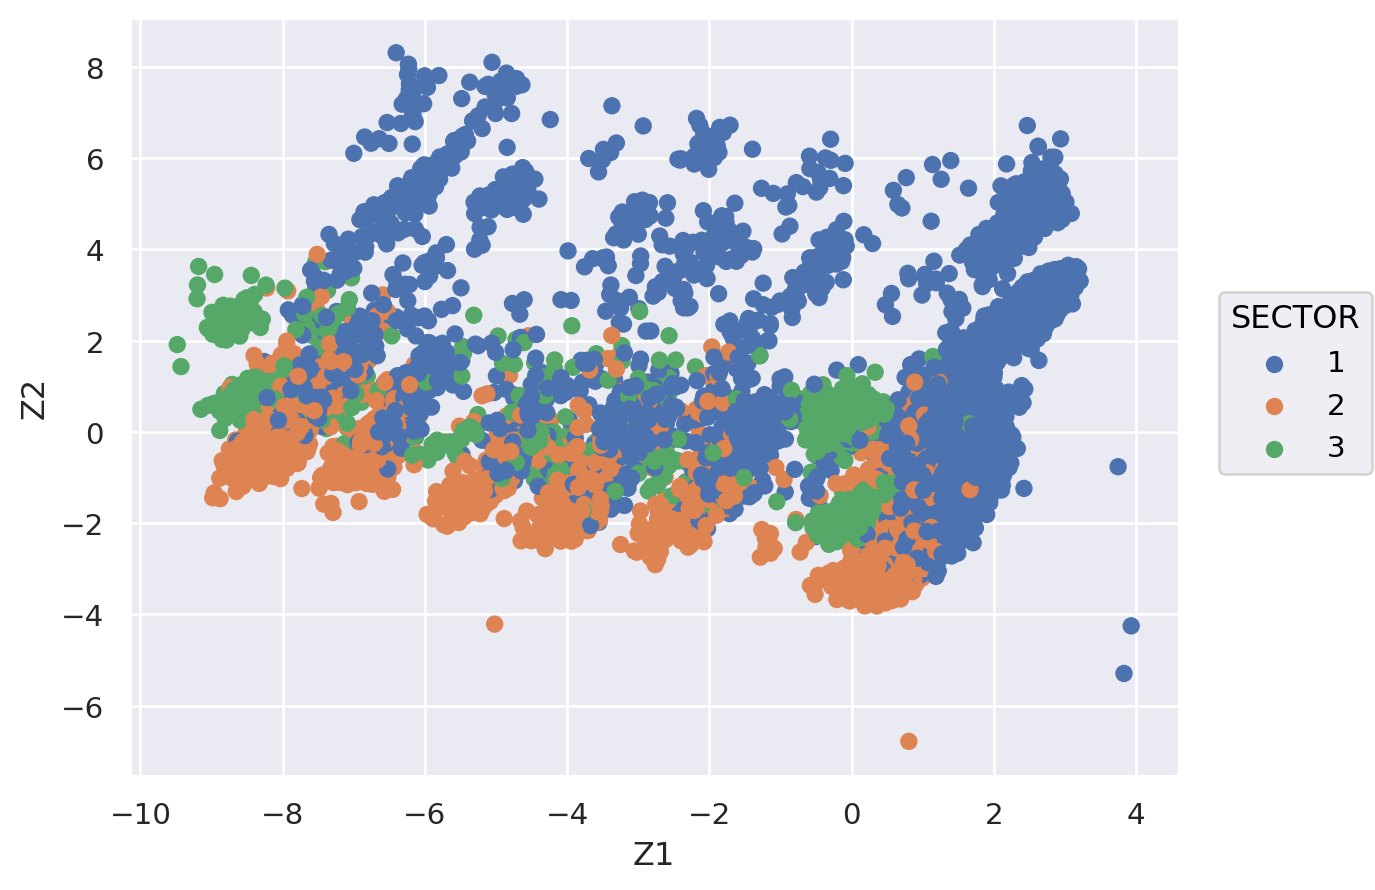

In [33]:
columnas_no_continuas = ["SECTOR", *columnas_a_convertir_a_dummy]
columnas_continuas    = df_clasificacion.columns.difference(columnas_no_continuas)

scaler = StandardScaler()
df_clasificacion[columnas_continuas] = scaler.fit_transform(df_clasificacion[columnas_continuas])

X = df_clasificacion.drop(columns=["SECTOR"])
y = df_clasificacion["SECTOR"]

pca = PCA(n_components=2)
componentes_principales = pca.fit_transform(X)

df_pca = pd.DataFrame(
    data=componentes_principales,
    columns=["Z1", "Z2"]
)

df_pca["SECTOR"] = y.astype(str).values

(
    so.Plot(df_pca, x="Z1", y="Z2", color="SECTOR")
    .add(so.Dot())
    .scale(color=so.Nominal(order=np.unique(df_pca["SECTOR"]).tolist()))
)

## Ejercicio 17

### Ítem a)

In [35]:
X = df_datos.drop(columns=["SECTOR"])
y = df_datos["SECTOR"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

### Ítem b)

In [36]:
X_train_scaled = scaler.fit_transform(X_train)

### Ítem c)

In [38]:
valores_k_impares = [k for k in range(1, 21) if k % 2 != 0]

resultados_cv = []
for k in valores_k_impares:
    knn = KNeighborsClassifier(n_neighbors=k)
    
    puntajes = cross_val_score(
        knn, X_train_scaled, y_train,
        cv=5,
        scoring="accuracy"
    )

    resultados_cv.append(puntajes.mean())

k_optimo = valores_k_impares[np.argmax(resultados_cv)]
print(f"K óptimo: {k_optimo}")

K óptimo: 13


### Ítem d)

In [42]:
X_test_scaled = scaler.transform(X_test)

knn_con_k_optimo = KNeighborsClassifier(n_neighbors=k_optimo)
knn_con_k_optimo.fit(X_train_scaled, y_train)

y_pred = knn_con_k_optimo.predict(X_test_scaled)

precision_test = knn_con_k_optimo.score(X_test_scaled, y_test)
print(f"Precisión: {(100 * precision_test):.4f}%")

Precisión: 93.3489%


### Ítem e)

In [44]:
df_datos_sin_variables_elegidas = df_datos.drop(columns=["CH06", "P47T", "NIVEL_ED"])

X = df_datos_sin_variables_elegidas.drop(columns=["SECTOR"])
y = df_datos_sin_variables_elegidas["SECTOR"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

X_train_scaled = scaler.fit_transform(X_train)

resultados_cv = []
for k in valores_k_impares:
    knn = KNeighborsClassifier(n_neighbors=k)

    puntajes = cross_val_score(
        knn, X_train_scaled, y_train,
        cv=5, scoring="accuracy"
    )

    resultados_cv.append(puntajes.mean())

k_optimo = valores_k_impares[np.argmax(resultados_cv)]
print(f"K óptimo: {k_optimo}")

X_test_scaled = scaler.transform(X_test)

knn_con_k_optimo = KNeighborsClassifier(n_neighbors=k_optimo)
knn_con_k_optimo.fit(X_train_scaled, y_train)

y_pred = knn_con_k_optimo.predict(X_test_scaled)
precision_test = knn_con_k_optimo.score(X_test_scaled, y_test)

print(f"Precisión: {(100 * precision_test):.4f}%")

K óptimo: 5
Precisión: 93.5526%


# Regresión